# Подготовка модели распознавания рукописных букв и цифр

In [3]:
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor, Compose, Normalize
from torchinfo import summary
from torchvision import datasets
import matplotlib.pyplot as plt


dataset = datasets.EMNIST('data/', split='balanced', download=False)

In [4]:
mapping_path = Path('data/EMNIST/raw/emnist-balanced-mapping.txt')

mapping = {}

with open(mapping_path, 'r') as file:
    for line in file:
        label, ascii_code = map(int, line.split())
        mapping[label] = chr(ascii_code)

print(mapping)
print(len(mapping))

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z', 36: 'a', 37: 'b', 38: 'd', 39: 'e', 40: 'f', 41: 'g', 42: 'h', 43: 'n', 44: 'q', 45: 'r', 46: 't'}
47


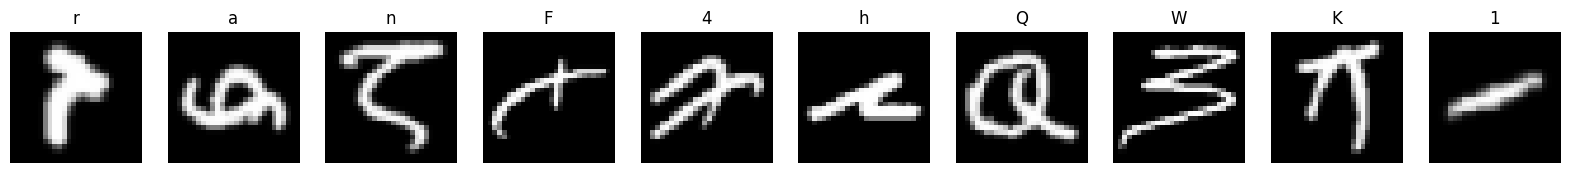

In [10]:
fig, axs = plt.subplots(1, 10, figsize=(20, 5))
for i in range(10):
    axs[i].imshow(dataset[i][0], cmap='gray')
    axs[i].set_title(mapping[dataset[i][1]])
    axs[i].axis('off')
plt.show()